In [2]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import io
from itertools import compress

class DominantColors:

    CLUSTERS = None
    IMAGE = None
    COLORS = None
    LABELS = None

    def __init__(self, image, clusters=3):
        self.CLUSTERS = clusters
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        self.IMAGE = img.reshape((img.shape[0] * img.shape[1], 3))

        #using k-means to cluster pixels
        kmeans = KMeans(n_clusters = self.CLUSTERS)
        kmeans.fit(self.IMAGE)

        #the cluster centers are our dominant colors.
        self.COLORS = kmeans.cluster_centers_
        self.LABELS = kmeans.labels_

    def rgb_to_hex(self, rgb):
        return '#%02x%02x%02x' % (int(rgb[0]), int(rgb[1]), int(rgb[2]))

    # Return a list in order of color that appeared most often.
    def getHistogram(self):
        numLabels = np.arange(0, self.CLUSTERS+1)
        #create frequency count tables
        (hist, _) = np.histogram(self.LABELS, bins = numLabels)
        hist = hist.astype("float")
        hist /= hist.sum()

        colors = self.COLORS
        #descending order sorting as per frequency count
        colors = colors[(-hist).argsort()]
        hist = hist[(-hist).argsort()]
        for i in range(self.CLUSTERS):
            colors[i] = colors[i].astype(int)
        # Blue mask 
        fil = [colors[i][2] < 250 and colors[i][0] > 10 for i in range(self.CLUSTERS)]
        colors = list(compress(colors, fil))
        return colors, hist

    def plotHistogram(self):
        colors, hist = self.getHistogram()
        #creating empty chart
        chart = np.zeros((50, 500, 3), np.uint8)
        start = 0

        #creating color rectangles
        for i in range(len(colors)):
            end = start + hist[i] * 500
            r,g,b = colors[i]
            #using cv2.rectangle to plot colors
            cv2.rectangle(chart, (int(start), 0), (int(end), 50), (r,g,b), -1)
            start = end

        #display chart
        plt.figure()
        plt.axis("off")
        plt.imshow(chart)
        plt.show()

        return colors

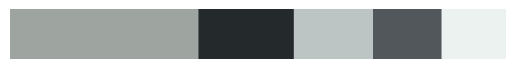

Cores dominantes (HEX):
#9ea4a0
#242a2c
#bdc5c4
#51575b
#ebf2f0


In [3]:
img_pil = cv2.imread("../static/sua_foto.jpg")

#Converter para o formato que o OpenCV entende (numpy array)
image = np.array(img_pil)

image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

# Instanciar e testar
dc = DominantColors(image_bgr, clusters=5)
colors = dc.plotHistogram()

# Ver os resultados em HEX
print("Cores dominantes (HEX):")
for c in colors:
    print(dc.rgb_to_hex(c))